In [1]:
import re
from pathlib import Path

import cmocean.cm as cmo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from cycler import cycler
from flox.xarray import xarray_reduce
from matplotlib import gridspec
from scipy.stats import distributions
from tqdm import tqdm

In [2]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
BROADSCALE_FILE = DATA_DIR / "broadscale/Nitrate_AllProjects.csv"

In [3]:
def bin_profiles(d, z):
    types = [d[i].dtype for i in d]
    var_names = list(d.keys())
    exclude = []
    for i, t in enumerate(types):
        if not (np.issubdtype(t, np.number)):
            exclude.append(var_names[i])
    d = d.drop_vars(exclude)
    out = xarray_reduce(
        d,
        d["time"],
        d["depth"],
        func="nanmean",
        expected_groups=(None, z),
        isbin=[False, True],
        method="map-reduce",
        skipna=True,
    )
    depth = np.array([x.mid for x in out.depth_bins.values])
    out["depth"] = (["depth" + "_bins"], depth)
    out = out.swap_dims({"depth" + "_bins": "depth"})
    return out

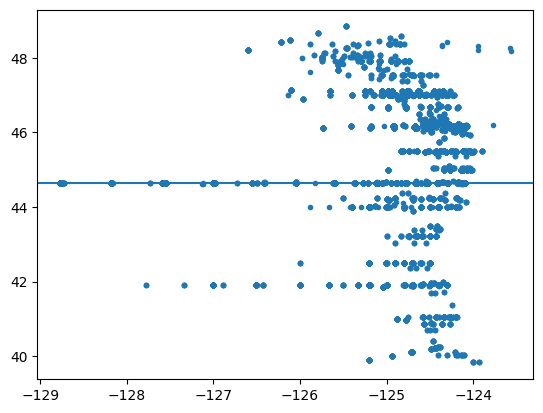

In [4]:
broadscale = pd.read_csv(
    BROADSCALE_FILE,
    header=0,
    index_col=False,
    names=[
        "id",
        "code",
        "date",
        "transect",
        "station",
        "lat",
        "lon",
        "depth",
        "no2",
        "no3",
        "no2+no3",
        "comments",
    ],
)
broadscale = broadscale.loc[broadscale.lon < 0]
nhl_lat = broadscale.loc[broadscale["transect"] == "Newport Hydrographic"].lat.median()
broadscale = broadscale.loc[(np.abs(broadscale["lat"] - nhl_lat) < 5)]
broadscale["time"] = pd.to_datetime(broadscale.date)
broadscale.set_index("time", inplace=True)
broadscale = broadscale.to_xarray()
plt.plot(broadscale.lon, broadscale.lat, ".")
plt.axhline(nhl_lat)
broadscale["transect_abbr"] = xr.DataArray(
    xr.apply_ufunc(
        lambda d: [re.split("(\\d+)", str(s))[0] for s in d], broadscale.station.values
    ),
    dims="time",
)

In [5]:
broadscale.where(broadscale.depth < 100).no3.max()

<xarray.DataArray 'no3' ()> Size: 8B
array(39.34120178)

In [6]:
transect_station = np.array(
    [broadscale.transect_abbr.values, broadscale.transect.values]
).T.astype(str)
transect_station = np.unique(transect_station, axis=0)
exclude_transect = transect_station[transect_station[:, 1] == "nan"].T[0]
transect_station = transect_station[
    (transect_station[:, 1] != "nan") & (transect_station[:, 0] != "nan")
]
transect_station = dict(transect_station)
transect_lats = dict(
    zip(
        transect_station.keys(),
        np.array(
            [
                broadscale.where(broadscale.transect_abbr == ta, drop=True)
                .lat.median()
                .values
                for ta in transect_station.keys()
            ]
        ),
    )
)

In [7]:
stations = np.array(
    [t for t in dict(zip(broadscale.station.values, broadscale.transect.values)).keys()]
)
nhl_lat = (
    broadscale.where(broadscale.transect == "Newport Hydrographic", drop=True)
    .lat.median()
    .data
)
t = "Newport Hydrographic"
broadscale_binned = []
depth = np.concatenate(
    [np.arange(0, 300, 10), np.arange(300, 500, 50), np.arange(500, 4000, 100)]
)
for s in tqdm(stations):
    if s != "nan" and re.split("(\\d+)", s)[0] not in exclude_transect:
        transect = transect_station[re.split("(\\d+)", s)[0]]
        transect_lat = transect_lats[re.split("(\\d+)", s)[0]]
        lat = (
            broadscale.where(broadscale.transect == transect, drop=True)
            .lat.median()
            .values
        )
        temp = broadscale.where(broadscale.station == s, drop=True)
        temp = bin_profiles(temp, depth)
        lon = temp.lon.median().values
        temp = temp.expand_dims({"station": [s]}).drop_vars("lat")
        temp["lat"] = (["station"], [lat])
        temp["lon"] = (["station"], [lon])
        temp = temp.where(np.abs(temp.lat - transect_lat) < 0.025, drop=True)
        broadscale_binned.append(temp)

broadscale_binned = xr.concat(broadscale_binned, dim="station")

100%|██████████| 408/408 [00:42<00:00,  9.70it/s] 


In [8]:
len(
    xr.apply_ufunc(
        lambda d: [re.split(r"(\d+)", str(s))[0] for s in d],
        broadscale_binned.station.values,
    )
)

326

In [9]:
broadscale_binned["transect_abbr"] = xr.DataArray(
    xr.apply_ufunc(
        lambda d: [re.split(r"(\d+)", str(s))[0] for s in d],
        broadscale_binned.station.values,
    ),
    dims="station",
)

In [10]:
lats = []
for t in transect_station.values():
    lat = broadscale.where(broadscale.transect == t, drop=True).lat.median().values
    lats.append(lat)
lats = np.array(lats)
transect_station = dict(
    np.array(list(transect_station.items()))[np.argsort(lats)][::-1]
)
lats = np.sort(lats)[::-1]
lats

array([48.41999817, 48.37133408, 48.12226486, 48.07925034, 48.03609848,
       47.91999817, 47.68016815, 47.53133392, 47.46666718, 47.37266541,
       47.2763176 , 47.00273514, 46.91608047, 46.67016602, 46.49891663,
       46.49891663, 46.25      , 46.21099854, 46.19966507, 46.15999985,
       46.05466843, 46.03878402, 46.00808334, 45.49750137, 45.37320328,
       45.        , 44.65169907, 44.3719902 , 44.25      , 44.20013428,
       44.        , 43.90000153, 43.40304947, 43.21659851, 43.21659851,
       43.03858566, 42.5       , 42.37389755, 41.90000153, 41.70681763,
       41.37323761, 41.05833054, 40.87039948, 40.7060318 , 40.10978317,
       40.03839874, 39.84120178])

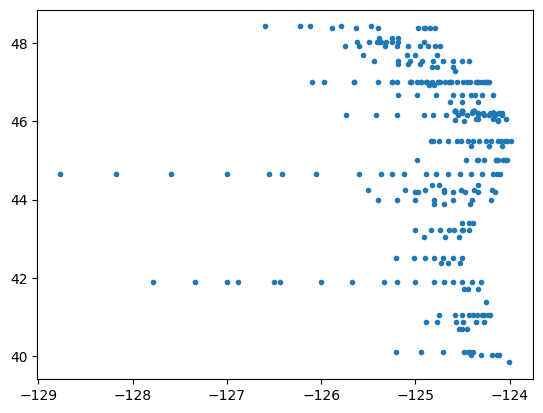

In [11]:
plt.plot(broadscale_binned.lon, broadscale_binned.lat, ".")

In [12]:
broadscale_binned.sel(
    station=[s.startswith("NH") for s in broadscale_binned.station.values]
)

<xarray.Dataset> Size: 31MB
Dimensions:        (station: 22, time: 870, depth: 68)
Coordinates:
  * depth          (depth) float64 544B 5.0 15.0 25.0 ... 3.75e+03 3.85e+03
  * time           (time) datetime64[ns] 7kB 1997-03-21 ... 2022-09-26
  * station        (station) object 176B 'NH05' 'NH15' 'NH10' ... 'NH50' 'NH30'
    depth_bins     (depth) object 544B (0, 10] (10, 20] ... (3800, 3900]
Data variables:
    lon            (station) float64 176B -124.2 -124.4 -124.3 ... -125.2 -124.8
    no2            (station, time, depth) float64 10MB nan nan nan ... nan nan
    no3            (station, time, depth) float64 10MB nan nan nan ... nan nan
    no2+no3        (station, time, depth) float64 10MB nan nan nan ... nan nan
    lat            (station) float64 176B 44.65 44.65 44.65 ... 44.65 44.65
    transect_abbr  (station) <U3 264B 'NH' 'NH' 'NH' 'NH' ... 'NH' 'NH' 'NH'

In [13]:
def reshape_plots(fig, axs, r, c):
    gs = gridspec.GridSpec(r, c, fig)
    for i, (ax, g) in enumerate(zip(axs, gs)):
        ax.set_subplotspec(g)

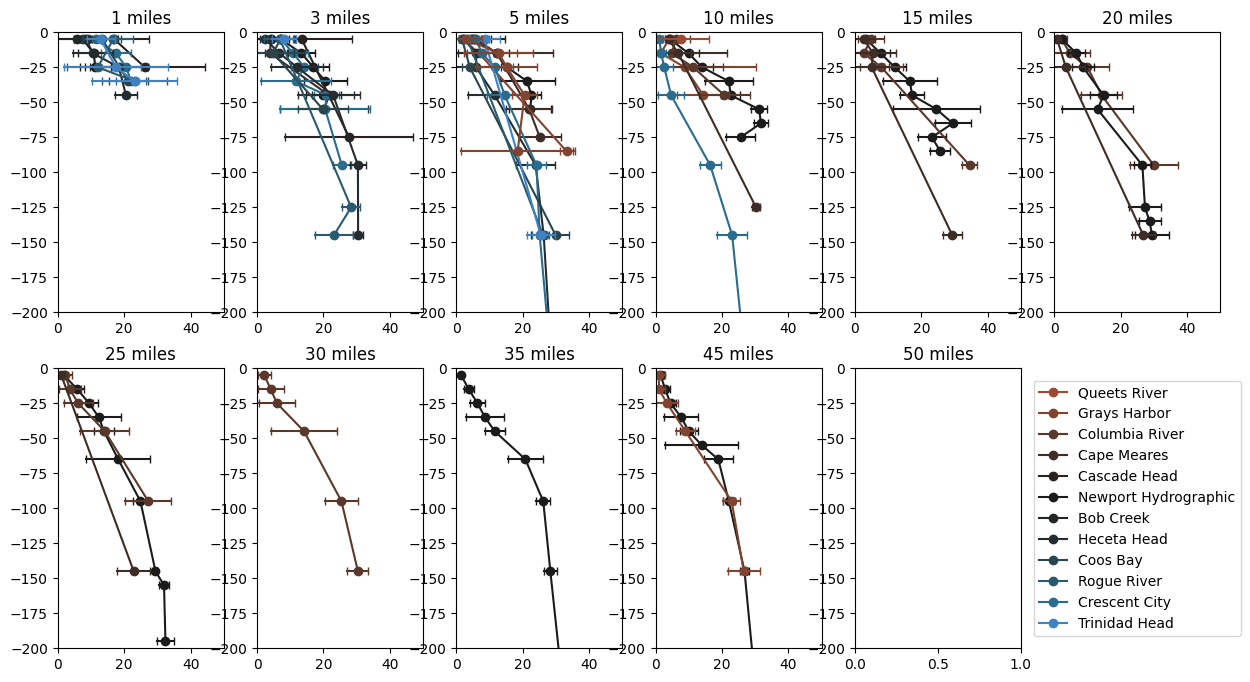

In [14]:
cc = cycler(marker=["o", "X", "+", "*", "o", "X", "+", "*", "o", "X", "+"]) + cycler(
    color=[
        "#4477AA",
        "#EE6677",
        "#228833",
        "#CCBB44",
        "#66CCEE",
        "#AA3377",
        "#BBBBBB",
        "#4477AA",
        "#EE6677",
        "#228833",
        "#CCBB44",
    ]
)
cc = cycler(
    color=[
        "#CC6677",
        "#332288",
        "#DDCC77",
        "#117733",
        "#88CCEE",
        "#882255",
        "#44AA99",
        "#999933",
        "#AA4499",
        "#DDDDDD",
        "#000000",
    ]
) * cycler(marker=["o"])
cc = list(cc)

cmap = cmo.tools.crop_by_percent(cmo.balance_i, 20, which="both")
lats_reldiff = 0.5 * (lats - nhl_lat) / np.abs((lats - nhl_lat)[-1]) + 0.5

min_count = 3
station_miles = np.array([1, 3, 5, 10, 15, 20, 25, 30, 35, 45, 50])
fig, axs = plt.subplots(1, len(station_miles) + 1, figsize=(15, 8))
handles, labels = [], []
for i, mile in enumerate(station_miles):
    # axs[i].set_prop_cycle(cc)
    axs[i].set_title(f"{mile} miles")
    temp = broadscale_binned.station.values

    for stat in broadscale_binned.station.values:
        temp = broadscale_binned.sel(station=stat)
        if int(re.split("(\\d+)", stat)[1]) == mile:
            broadscale_depth = temp.depth.values
            broadscale_mean = temp.no3.mean(dim="time").values
            broadscale_std = temp.no3.std(dim="time").values
            broadscale_count = temp.no3.count(dim="time").values
            broadscale_depth = broadscale_depth[broadscale_count > min_count]
            broadscale_mean = broadscale_mean[broadscale_count > min_count]
            broadscale_std = broadscale_std[broadscale_count > min_count]
            broadscale_count = broadscale_count[broadscale_count > min_count]
            broadscale_ci = np.array(
                [
                    std / np.sqrt(n) * distributions.t(n - 1).isf(0.025)
                    for std, n in zip(broadscale_std, broadscale_count)
                ]
            )
            cc_idx = list(transect_station.keys()).index(re.split("(\\d+)", stat)[0])
            if len(broadscale_mean) > 0:
                axs[i].plot(
                    broadscale_mean,
                    -broadscale_depth,
                    marker="o",
                    color=cmap(lats_reldiff)[cc_idx],
                    label=transect_station[re.split("(\\d+)", stat)[0]],
                )
                axs[i].plot(
                    np.stack(
                        [
                            broadscale_mean - broadscale_ci,
                            broadscale_mean + broadscale_ci,
                        ]
                    ),
                    np.stack([-broadscale_depth, -broadscale_depth]),
                    marker="|",
                    color=cmap(lats_reldiff)[cc_idx],
                )
                # axs[i].plot(broadscale_count, -broadscale_depth, marker='o', color=cmap(lats_reldiff[cc_idx]))
                axs[i].set_xlim(0, 50)
    hand, lab = axs[i].get_legend_handles_labels()
    handles.append(hand)
    labels.append(lab)

axs[-1].set_axis_off()
reshape_plots(fig, axs, 2, 6)
handles = [hj for hi in handles for hj in hi]
labels = [lj for li in labels for lj in li]
labels, handles = np.array(
    [(hand, lab) for hand, lab in dict(zip(labels, handles)).items()]
).T
handles = handles[
    np.argsort(
        np.array(
            [
                transect_lats[
                    list(transect_station.keys())[
                        list(transect_station.values()).index(lab)
                    ]
                ]
                for lab in labels
            ]
        )
    )[::-1]
]
labels = labels[
    np.argsort(
        np.array(
            [
                transect_lats[
                    list(transect_station.keys())[
                        list(transect_station.values()).index(lab)
                    ]
                ]
                for lab in labels
            ]
        )
    )[::-1]
]
axs[-1].legend(handles, labels, loc="center", bbox_to_anchor=(0.5, 0.5))
[ax.set_ylim(-200, 0) for ax in axs]
pass

[(-200.0, 0.0), (-200.0, 0.0), (-200.0, 0.0), (-200.0, 0.0), (-200.0, 0.0)]

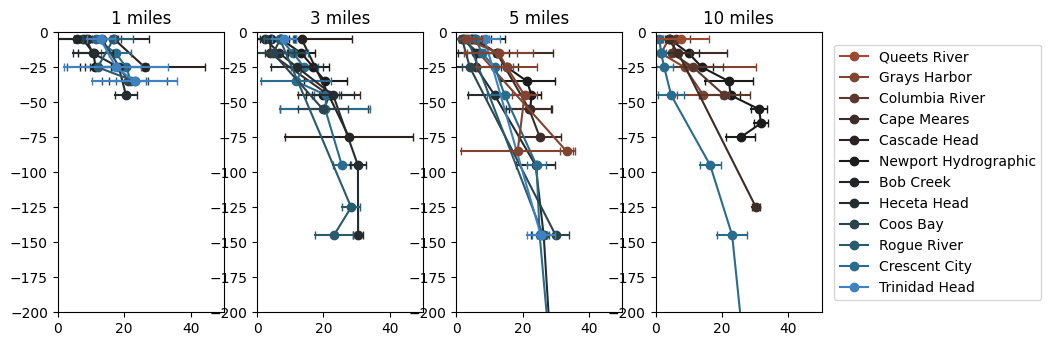

In [15]:
cc = cycler(marker=["o", "X", "+", "*", "o", "X", "+", "*", "o", "X", "+"]) + cycler(
    color=[
        "#4477AA",
        "#EE6677",
        "#228833",
        "#CCBB44",
        "#66CCEE",
        "#AA3377",
        "#BBBBBB",
        "#4477AA",
        "#EE6677",
        "#228833",
        "#CCBB44",
    ]
)
cc = cycler(
    color=[
        "#CC6677",
        "#332288",
        "#DDCC77",
        "#117733",
        "#88CCEE",
        "#882255",
        "#44AA99",
        "#999933",
        "#AA4499",
        "#DDDDDD",
        "#000000",
    ]
) * cycler(marker=["o"])
cc = list(cc)

cmap = cmo.tools.crop_by_percent(cmo.balance_i, 20, which="both")
lats_reldiff = 0.5 * (lats - nhl_lat) / np.abs((lats - nhl_lat)[-1]) + 0.5

min_count = 3
station_miles = np.array([1, 3, 5, 10])
fig, axs = plt.subplots(1, len(station_miles) + 1, figsize=(15, 8))
handles, labels = [], []
for i, mile in enumerate(station_miles):
    # axs[i].set_prop_cycle(cc)
    axs[i].set_title(f"{mile} miles")
    temp = broadscale_binned.station.values

    for stat in broadscale_binned.station.values:
        temp = broadscale_binned.sel(station=stat)
        if int(re.split("(\\d+)", stat)[1]) == mile:
            broadscale_depth = temp.depth.values
            broadscale_mean = temp.no3.mean(dim="time").values
            broadscale_std = temp.no3.std(dim="time").values
            broadscale_count = temp.no3.count(dim="time").values
            broadscale_depth = broadscale_depth[broadscale_count > min_count]
            broadscale_mean = broadscale_mean[broadscale_count > min_count]
            broadscale_std = broadscale_std[broadscale_count > min_count]
            broadscale_count = broadscale_count[broadscale_count > min_count]
            broadscale_ci = np.array(
                [
                    std / np.sqrt(n) * distributions.t(n - 1).isf(0.025)
                    for std, n in zip(broadscale_std, broadscale_count)
                ]
            )
            cc_idx = list(transect_station.keys()).index(re.split("(\\d+)", stat)[0])
            if len(broadscale_mean) > 0:
                axs[i].plot(
                    broadscale_mean,
                    -broadscale_depth,
                    marker="o",
                    color=cmap(lats_reldiff)[cc_idx],
                    label=transect_station[re.split("(\\d+)", stat)[0]],
                )
                axs[i].plot(
                    np.stack(
                        [
                            broadscale_mean - broadscale_ci,
                            broadscale_mean + broadscale_ci,
                        ]
                    ),
                    np.stack([-broadscale_depth, -broadscale_depth]),
                    marker="|",
                    color=cmap(lats_reldiff)[cc_idx],
                )
                # axs[i].plot(broadscale_count, -broadscale_depth, marker='o', color=cmap(lats_reldiff[cc_idx]))
                axs[i].set_xlim(0, 50)
    hand, lab = axs[i].get_legend_handles_labels()
    handles.append(hand)
    labels.append(lab)

axs[-1].set_axis_off()
reshape_plots(fig, axs, 2, 6)
handles = [hj for hi in handles for hj in hi]
labels = [lj for li in labels for lj in li]
labels, handles = np.array(
    [(hand, lab) for hand, lab in dict(zip(labels, handles)).items()]
).T
handles = handles[
    np.argsort(
        np.array(
            [
                transect_lats[
                    list(transect_station.keys())[
                        list(transect_station.values()).index(lab)
                    ]
                ]
                for lab in labels
            ]
        )
    )[::-1]
]
labels = labels[
    np.argsort(
        np.array(
            [
                transect_lats[
                    list(transect_station.keys())[
                        list(transect_station.values()).index(lab)
                    ]
                ]
                for lab in labels
            ]
        )
    )[::-1]
]
axs[-1].legend(handles, labels, loc="center", bbox_to_anchor=(0.5, 0.5))
[ax.set_ylim(-200, 0) for ax in axs]

In [16]:
(
    broadscale_binned.sel(
        station=[s.startswith("GH") for s in broadscale_binned.station.values]
    ).lat.mean()
    - broadscale_binned.sel(
        station=[s.startswith("NH") for s in broadscale_binned.station.values]
    ).lat.mean()
)

<xarray.DataArray 'lat' ()> Size: 8B
array(2.35103607)

In [17]:
(
    broadscale_binned.sel(
        station=[s.startswith("NH") for s in broadscale_binned.station.values]
    ).lat.mean()
    - broadscale_binned.sel(
        station=[s.startswith("TH") for s in broadscale_binned.station.values]
    ).lat.mean()
)

<xarray.DataArray 'lat' ()> Size: 8B
array(3.59336853)

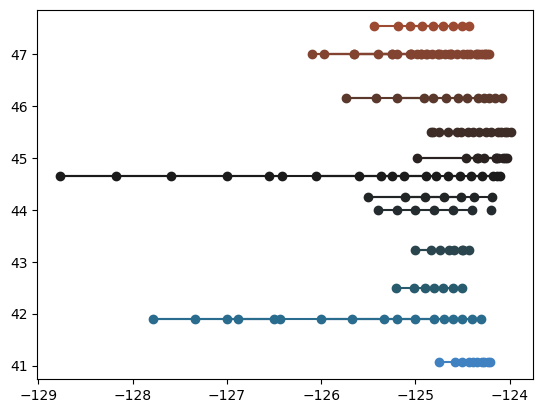

In [18]:
for (stat, trans), lat_rel in zip(transect_station.items(), lats_reldiff):
    if trans in labels:
        temp = broadscale_binned.where(
            broadscale_binned.transect_abbr == stat, drop=True
        )
        plt.plot(temp.lon, temp.lat, "-o", color=cmap(lat_rel), label=trans)